In [3]:
from cil.io import ZEISSDataReader
import numpy as np
import matplotlib.pyplot as plt
from cil.io import TIFFStackReader
import plotly.graph_objects as go
import plot_library as pl
from scipy.ndimage import rotate
from scipy.interpolate import griddata
import SimpleITK as sitk

In [4]:
reconpath0 = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/blackbeauty_/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1_recon.txm"
reconpath_neutron = "C:/Users/msaca/OneDrive - Danmarks Tekniske Universitet/P20212875_Nice data/04_evaluation/fullrecon"

In [5]:
reader = ZEISSDataReader(reconpath0)
recon_xray_ = reader.read()
recon_xray = pl.array_normalizer(recon_xray_.as_array().astype(np.float32))

In [6]:
roi = {'axis_0': (100, 1113, 1)}
reader = TIFFStackReader(reconpath_neutron,roi=roi)
recon_neutron = pl.array_normalizer(reader.read())

In [209]:
class Registrator():

    def __init__(self, fixed_data=None, moving_data=None):
        self.fixed = fixed_data
        self.moving = moving_data

    def add_data(self, fixed_data=None, moving_data=None):
        self.fixed = fixed_data
        self.moving = moving_data
        
    def downsize(self,block_size = (30,30,30), final_size_target = None ,fixed_or_moving = 'fixed'):
        if fixed_or_moving == 'fixed':
            matrix = self.fixed
        elif fixed_or_moving == 'moving':
            matrix = self.moving
        else:
            raise ValueError('Specify fixed or moving')
        if final_size_target is not None:
            block_size = (np.max(matrix.shape)//final_size_target, np.max(matrix.shape)//final_size_target,np.max(matrix.shape)//final_size_target)
        print(block_size)
        # Calculate the padding needed to make each dimension a multiple of 20
        pad_x = (block_size[0] - matrix.shape[0] % block_size[0]) % block_size[0]
        pad_y = (block_size[1] - matrix.shape[1] % block_size[1]) % block_size[1]
        pad_z = (block_size[2] - matrix.shape[2] % block_size[2]) % block_size[2]

        # Pad the matrix with zeros to make its dimensions multiples of 20
        padded_matrix = np.pad(matrix, ((0, pad_x), (0, pad_y), (0, pad_z)), mode='constant', constant_values=0)

        # Reshape the padded matrix into blocks of 20x20x20
        reshaped_matrix = padded_matrix.reshape(
            padded_matrix.shape[0] // block_size[0], block_size[0],
            padded_matrix.shape[1] // block_size[1], block_size[1],
            padded_matrix.shape[2] // block_size[2], block_size[2]
        )

        # Take the mean across the 20x20x20 blocks
        downsized_matrix = reshaped_matrix.mean(axis=(1, 3, 5))
        if fixed_or_moving == 'fixed':
            self.fixed_d = downsized_matrix
        else:
            self.moving_d  =downsized_matrix

    def thresholder(self, threshold = 0.5, fixed_or_moving = 'fixed', plot=False, downsized = False):
        if downsized:
            if fixed_or_moving == 'fixed':
                self.fixed_d_mask = (self.fixed_d>threshold)*1.0
                if plot:
                    middle = np.shape(self.fixed_d)[0]//2
                    plt.imshow(self.fixed_d_mask[middle])
                    plt.show()
            elif fixed_or_moving == 'moving':
                self.moving_d_mask = (self.moving_d>threshold)*1.0
                if plot:
                    middle = np.shape(self.moving_d)[0]//2
                    plt.imshow(self.moving_d_mask[middle])
                    plt.show()
        else:
            if fixed_or_moving == 'fixed':
                self.fixed_mask = (self.fixed>threshold)*1.0
                if plot:
                    middle = np.shape(self.fixed)[0]//2
                    plt.imshow(self.fixed_mask[middle])
                    plt.show()
            elif fixed_or_moving == 'moving':
                self.moving_mask = (self.moving>threshold)*1.0
                if plot:
                    middle = np.shape(self.moving)[0]//2
                    plt.imshow(self.moving_mask[middle])
                    plt.show()

    def GetImageFromArray(self):
        if self.fixed is not None:
            self.IM_fixed = sitk.GetImageFromArray(self.fixed)
        if self.moving is not None:
            self.IM_moving = sitk.GetImageFromArray(self.moving)
        if self.fixed_d is not None:
            self.IM_fixed_d = sitk.GetImageFromArray(self.fixed_d)
        if self.moving_d is not None:
            self.IM_moving_d = sitk.GetImageFromArray(self.moving_d)

        if self.fixed_mask is not None:
            self.IM_fixed_mask = sitk.GetImageFromArray(self.fixed_mask)
        if self.moving_mask is not None:
            self.IM_moving_mask = sitk.GetImageFromArray(self.moving_mask)
        if self.fixed_d_mask is not None:
            self.IM_fixed_d_mask = sitk.GetImageFromArray(self.fixed_d_mask)
        if self.moving_d_mask is not None:
            self.IM_moving_d_mask = sitk.GetImageFromArray(self.moving_d_mask)

    def set_main(self,downsized = False, mask = True):
        if mask:
            if downsized:
                self.reference = self.fixed_d_mask
                self.adjust = self.moving_d_mask
            else:
                self.reference = self.fixed_mask
                self.adjust = self.moving_mask
        else:
            if downsized:
                self.reference = self.fixed_d
                self.adjust = self.moving_d
            else:
                self.reference = self.fixed
                self.adjust = self.moving

        self.reference = sitk.GetImageFromArray(self.reference)
        self.adjust = sitk.GetImageFromArray(self.adjust)

    def transform_initial(self):
        initial_transform = sitk.CenteredTransformInitializer(
        self.reference,                  # Reference (fixed) image
        self.adjust,                     # Moving (adjust) image
        sitk.Similarity3DTransform(),    # Use similarity transformation (translation, rotation, scaling)
        sitk.CenteredTransformInitializerFilter.GEOMETRY  # Align the centroids (geometry)
        )
        resampler = sitk.ResampleImageFilter()
        resampler.SetReferenceImage(self.reference)  # Reference image (fixed)
        resampler.SetInterpolator(sitk.sitkLinear)   # Interpolation method
        resampler.SetTransform(initial_transform)    # Apply the initial transform (aligned centroids)
        self.adjust = resampler.Execute(self.adjust)  # Resample the moving image

    def apply_similarity_transform(self, rx, ry, rz, tx, ty, tz, scale):
        """
        Applies a Similarity3DTransform to a moving image using the provided transformation parameters.
        
        :param moving_image: The moving image to which the transformation is applied.
        :param rx, ry, rz: Rotation angles in radians.
        :param tx, ty, tz: Translation values in mm.
        :param scale: Scaling factor (uniform).
        :return: Transformed moving image.
        """
        moving_image = self.adjust
        # Initialize a Similarity3DTransform and set its parameters
        similarity_transform = sitk.Similarity3DTransform()
        #similarity_transform.SetRotation(rx, ry, rz)
        versor = sitk.Versor()
        versor.SetRotation(rx, ry, rz)  # This will set the Versor (quaternion) from Euler angles

        # Set the Versor in the Similarity3DTransform
        similarity_transform.SetRotation(versor)
        #rotation_matrix = sitk.Euler3DTransform()
        #rotation_matrix.SetRotation(rx, ry, rz)
        #similarity_transform.SetMatrix(rotation_matrix.GetMatrix())
        similarity_transform.SetTranslation([tx, ty, tz])
        similarity_transform.SetScale(scale)

        # Resample the moving image with the specified transformation
        resampler = sitk.ResampleImageFilter()
        resampler.SetTransform(similarity_transform)
        resampler.SetSize(moving_image.GetSize())
        resampler.SetOutputOrigin(moving_image.GetOrigin())
        resampler.SetOutputSpacing(moving_image.GetSpacing())
        resampler.SetOutputDirection(moving_image.GetDirection())
        resampler.SetInterpolator(sitk.sitkLinear)

        # Apply the transformation and return the transformed image
        self.adjust = resampler.Execute(moving_image)


    def SetupRegistration(self):

        self.Reg = sitk.ImageRegistrationMethod()
        self.Reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=100)
        self.Reg.SetMetricSamplingStrategy(self.Reg.RANDOM)
        self.Reg.SetMetricSamplingPercentage(0.5)

        # Use a multi-resolution pyramid
        self.Reg.SetShrinkFactorsPerLevel([2, 2, 1])
        self.Reg.SetSmoothingSigmasPerLevel([10, 5, 0])
        # Configure the rigid transform for rotation and translation
        #initial_transform = sitk.CenteredTransformInitializer(
        #    self.reference,
        #    self.adjust,
        #    sitk.Similarity2DTransform() if self.reference.GetDimension() == 2 else sitk.Similarity3DTransform(),
        #    sitk.CenteredTransformInitializerFilter.GEOMETRY
        #)
        self.Reg.SetInitialTransform(sitk.Similarity3DTransform(), inPlace=False)
        self.Reg.SetOptimizerAsGradientDescent(learningRate=0.1,
                                        numberOfIterations=2000,
                                        convergenceMinimumValue=1e-6,
                                            convergenceWindowSize=10)
        
        #self.Reg.SetOptimizerAsLBFGSB(gradientConvergenceTolerance=1e-5,
        #                                numberOfIterations=500,
        #                                maximumNumberOfCorrections=5)

        self.Reg.SetOptimizerScalesFromPhysicalShift()
        self.Reg.SetInterpolator(sitk.sitkLinear)

    def ExecuteRegistration(self):
        self.registration_transform = self.Reg.Execute(self.reference, self.adjust)

    def get_transformation_parameters(self):
        if isinstance(self.registration_transform, sitk.CompositeTransform):
            # Get the first sub-transform, which should be the actual one applied
            final_transform = self.registration_transform.GetNthTransform(0)
        else:
            final_transform = self.registration_transform

        # Now print the parameters based on the actual transform type
        print("Base Transformation Type:", type(final_transform))
        if isinstance(final_transform, sitk.Euler2DTransform):
            angle, tx, ty = final_transform.GetParameters()
            return angle, tx, ty, type(final_transform)
        elif isinstance(final_transform, sitk.Similarity2DTransform):
            scale, angle, tx, ty = final_transform.GetParameters()
            return scale, angle, tx, ty, type(final_transform)
        elif isinstance(final_transform, sitk.Euler3DTransform):
            rx, ry, rz, tx, ty, tz = final_transform.GetParameters()
            return  rx, ry, rz, tx, ty, tz, type(final_transform)
        elif isinstance(final_transform, sitk.Similarity3DTransform):
            rx, ry, rz, tx, ty, tz, scale = final_transform.GetParameters()
            return rx, ry, rz, tx, ty, tz, scale, type(final_transform)

    def resample(self):         
        self.resampled = sitk.Resample(self.adjust, self.reference, self.registration_transform, 
                                         sitk.sitkLinear, 0.0, self.reference.GetPixelID())
        

    def convert_to_array(self, image):
        return sitk.GetArrayFromImage(image)
        

In [210]:
recons = Registrator(fixed_data=recon_xray, moving_data=recon_neutron)
recons.downsize(final_size_target = 100 ,fixed_or_moving = 'fixed')
recons.downsize(final_size_target = 100 ,fixed_or_moving = 'moving')
print('Downsizing finished')
#recons.thresholder(threshold = 0.2, fixed_or_moving = 'fixed', downsized = False)
recons.thresholder(threshold = 0.2, fixed_or_moving = 'fixed', downsized = True)

#recons.thresholder(threshold = 0.5, fixed_or_moving = 'moving', downsized = False)
recons.thresholder(threshold = 0.5, fixed_or_moving = 'moving', downsized = True)

(10, 10, 10)
(10, 10, 10)
Downsizing finished


In [211]:
recons.set_main(downsized = True, mask = True)
recons.transform_initial()
recons.apply_similarity_transform(0.1794787220564199, -0.01203072361145721, 0.15963195249711945, 10.598231566152547, 13.15330872494754, -19.86238178634364, 0.8809900493152882)

AttributeError: module 'SimpleITK' has no attribute 'Versor'

In [203]:
recons.SetupRegistration()
recons.ExecuteRegistration()

params = recons.get_transformation_parameters()
print(params)

Base Transformation Type: <class 'SimpleITK.SimpleITK.Similarity3DTransform'>
(0.07520239207946315, -0.1624945226446917, 0.10359734010549318, 24.125175649399676, 6.120984143883847, -8.993103388050832, 0.9449514684277266, <class 'SimpleITK.SimpleITK.Similarity3DTransform'>)


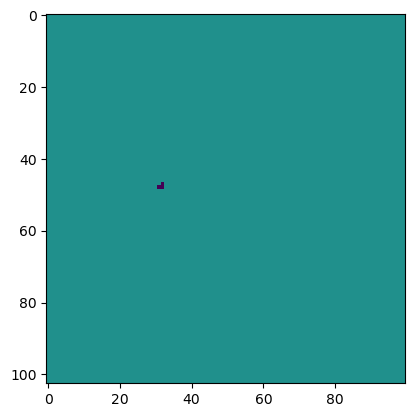

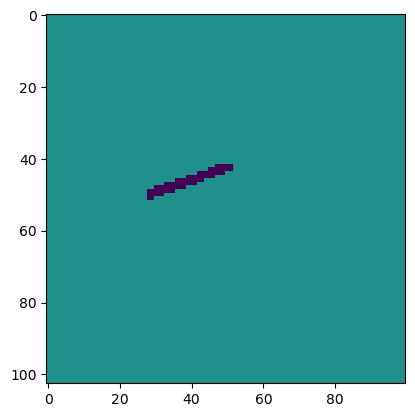

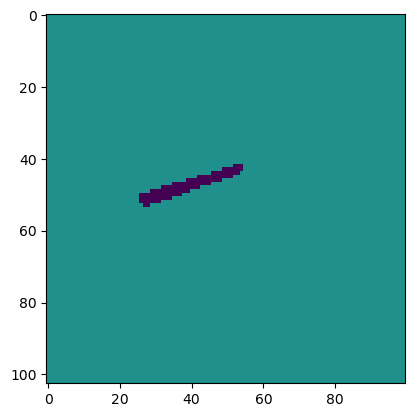

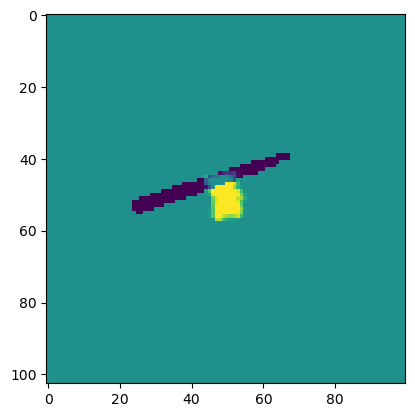

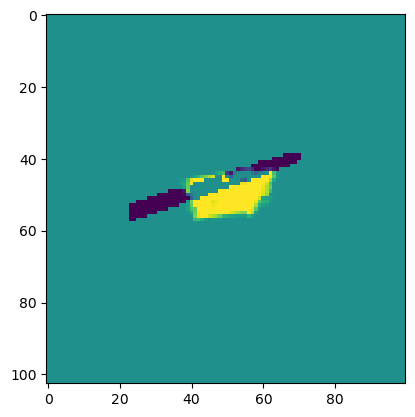

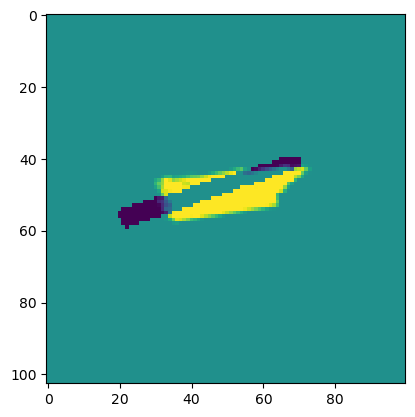

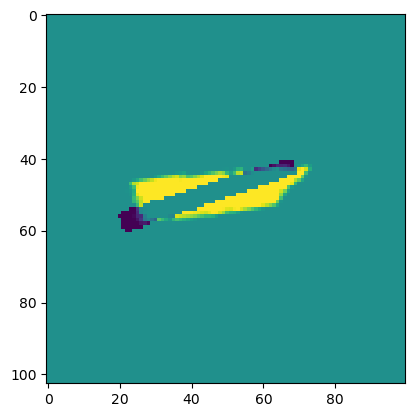

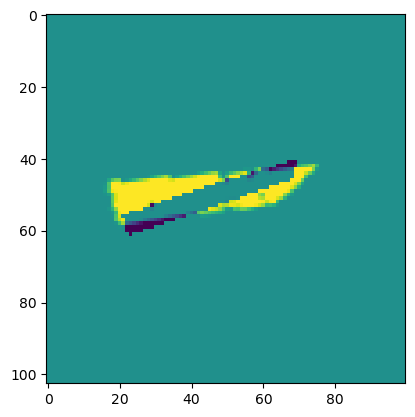

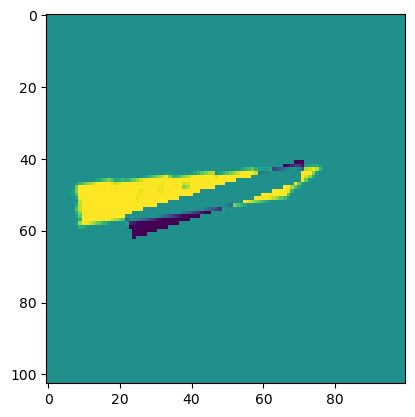

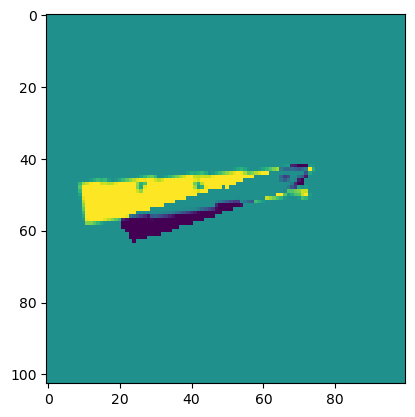

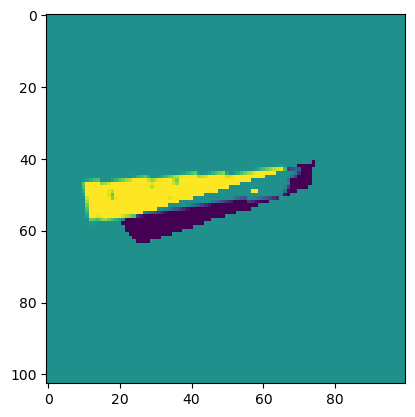

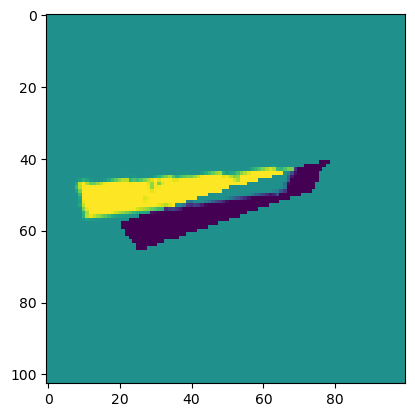

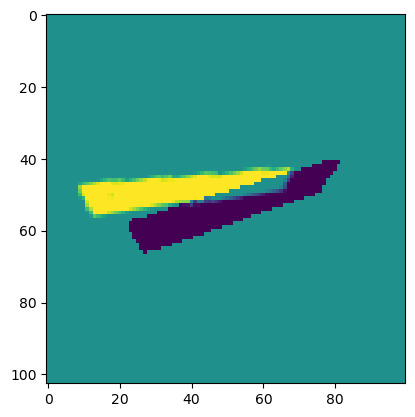

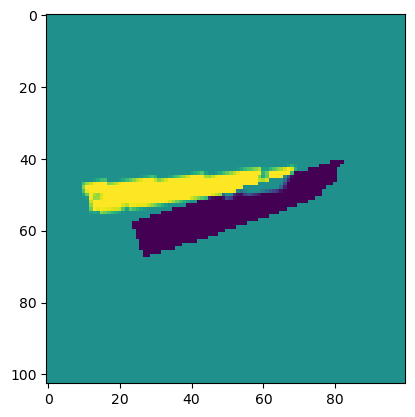

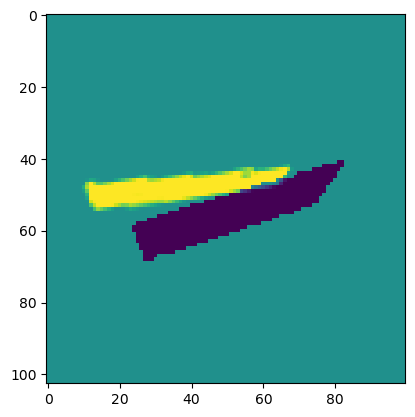

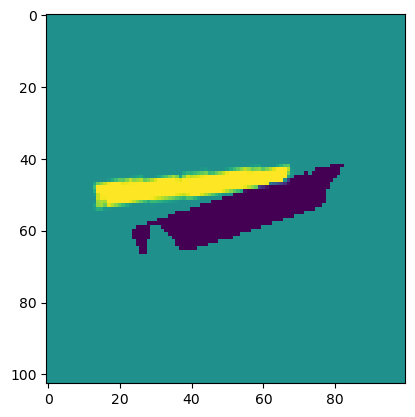

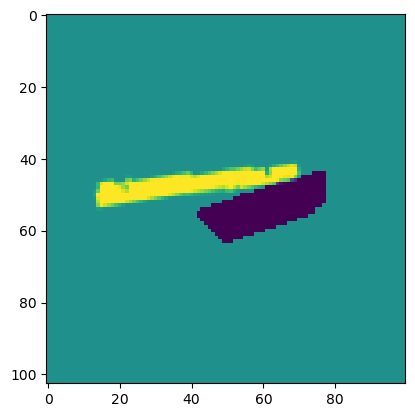

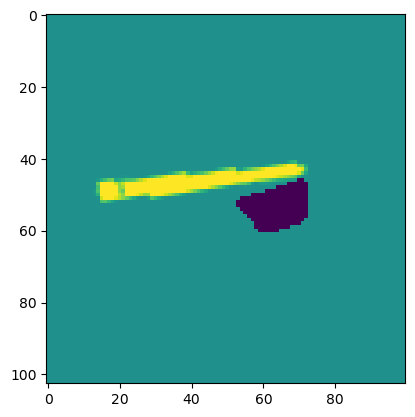

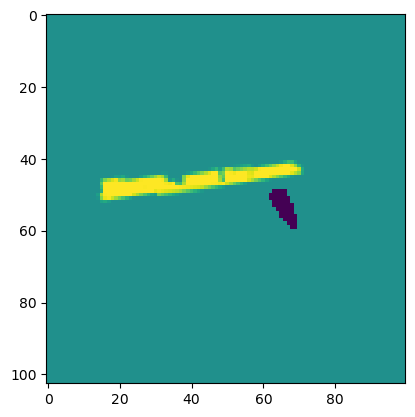

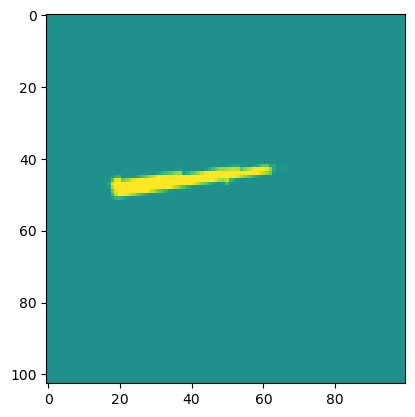

30217.8131647724
28591.0
17098822.769050244


In [205]:
recons.resample()
#recons.resample
moved = recons.convert_to_array(recons.adjust)
fixed = recons.fixed_d_mask

for slice_ in range(20):
    slice = slice_*5
    plt.imshow(moved[slice] - fixed[slice])
    plt.clim([-1,1])
    plt.show()
    #plt.imshow(moved[slice])
    #plt.show()
    #plt.imshow(fixed[slice])
    #plt.show()

print(np.sum(moved**2))
print(np.sum(fixed**2))
print(np.sum(fixed-moved)**2)